# Implementación de GoogLeNet (Inception v1) con Fashion-MNIST
Este cuaderno implementa la famosa arquitectura GoogLeNet, ganadora del reto ImageNet 2014, destacada por su eficiencia en el uso de parámetros mediante bloques paralelos.

## 1. Importaciones y Configuración Inicial
Preparamos el entorno. GoogLeNet es eficiente, pero al tener muchas capas paralelas, la GPU nos ayudará a procesar los tensores mucho más rápido.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

# Configuración del dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

Entrenando en: cpu


## 2. El Bloque Inception: El Corazón de GoogLeNet
La innovación clave aquí es el procesamiento en paralelo. Cada bloque tiene 4 rutas que extraen información de diferentes tamaños espaciales y luego las concatenan.

In [2]:
class Inception(nn.Module):
    def __init__(self, in_channels, c1, c2, c3, c4):
        super(Inception, self).__init__()
        # Ruta 1: Convolución 1x1 simple
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        
        # Ruta 2: 1x1 (reducción) -> 3x3
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)
        
        # Ruta 3: 1x1 (reducción) -> 5x5
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)
        
        # Ruta 4: MaxPool 3x3 -> 1x1
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)

    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        # Concatenamos en la dimensión de los canales (dim=1)
        return torch.cat((p1, p2, p3, p4), dim=1)

## 3. Construcción del Modelo GoogLeNet
GoogLeNet se compone de 5 bloques principales (b1 a b5). Nota cómo usa Global Average Pooling al final en lugar de capas densas gigantes, lo que reduce drásticamente el número de parámetros comparado con VGG.

In [3]:
class Flatten(nn.Module):
    def forward(self, input):
        return input.view(input.size(0), -1)

# Bloque 1
b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

# Bloque 2
b2 = nn.Sequential(nn.Conv2d(64, 64, kernel_size=1), nn.ReLU(),
                   nn.Conv2d(64, 192, kernel_size=3, padding=1), nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

# Bloque 3: Dos bloques Inception + MaxPool
b3 = nn.Sequential(Inception(192, 64, (96, 128), (16, 32), 32),
                   Inception(256, 128, (128, 192), (32, 96), 64),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

# Bloque 4: Cinco bloques Inception + MaxPool
b4 = nn.Sequential(Inception(480, 192, (96, 208), (16, 48), 64),
                   Inception(512, 160, (112, 224), (24, 64), 64),
                   Inception(512, 128, (128, 256), (24, 64), 64),
                   Inception(512, 112, (144, 288), (32, 64), 64),
                   Inception(528, 256, (160, 320), (32, 128), 128),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

# Bloque 5: Dos bloques Inception + Global Average Pooling
b5 = nn.Sequential(Inception(832, 256, (160, 320), (32, 128), 128),
                   Inception(832, 384, (192, 384), (48, 128), 128),
                   nn.AdaptiveAvgPool2d((1, 1)),
                   Flatten())

net = nn.Sequential(b1, b2, b3, b4, b5, nn.Linear(1024, 10)).to(device)

## 4. Preparación de Datos y Entrenamiento
Para que el entrenamiento sea eficiente, redimensionamos a $96 \times 96$.

In [4]:
# Transformaciones
transform = transforms.Compose([
    transforms.Resize(96),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Carga de Fashion-MNIST
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

# Entrenamiento
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

print("Iniciando entrenamiento...")
for epoch in range(3):
    net.train()
    pbar = tqdm(trainloader, desc=f"Época {epoch+1}/3")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(net(inputs), labels)
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=loss.item())

Iniciando entrenamiento...


Época 3/3: 100%|██████████| 469/469 [45:58<00:00,  5.88s/it, loss=0.206]


## 5. Visualización de Resultados
Veamos cómo se comporta esta red con sus múltiples rutas paralelas.

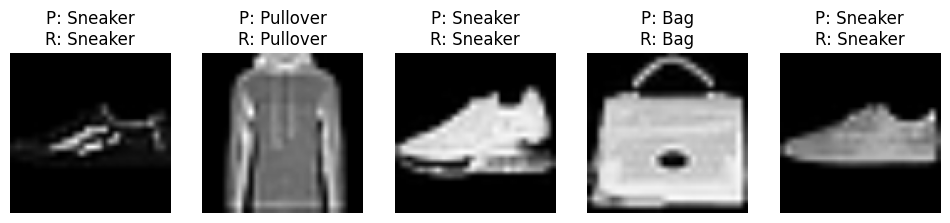

In [5]:
net.eval()
images, labels = next(iter(trainloader))
with torch.no_grad():
    outputs = net(images.to(device))
    _, preds = torch.max(outputs, 1)

plt.figure(figsize=(12, 4))
classes = trainset.classes
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"P: {classes[preds[i]]}\nR: {classes[labels[i]]}")
    plt.axis('off')
plt.show()

### ¿Por qué GoogLeNet?
A diferencia de VGG16, que tiene unos 138 millones de parámetros, GoogLeNet tiene solo unos 7 millones. Esto significa que aunque tiene más capas, los cálculos son mucho más ligeros para la GPU.